# Evaluation and Results

This notebook runs the full experiment matrix defined in Notebook 4,
aggregates per-fold results into summary tables, and produces
comparison visualisations for the thesis.

**Environment:** `ml_env`

**Prerequisites:** Run Notebooks 3 and 4 first (Notebook 4 defines
all functions used here; this notebook re-defines them for standalone use).

## Contents

1. Setup — imports, function definitions (copied from Notebook 4), data loading
2. Run full experiment matrix (400 experiments, 18 folds each)
3. Aggregate results into summary DataFrames
4. Comparison tables — baseline vs SFA, Group K-Fold vs K-Fold
5. Visualisations — bar charts, heatmaps
6. Export results to CSV and pickle

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import warnings
from time import time

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

warnings.filterwarnings("ignore", category=UserWarning)

## 1. Setup — Function Definitions

These are copied from Notebook 4 so this notebook can run standalone.
If you prefer, you can run Notebook 4 first in the same kernel session
and skip this section.

In [2]:
# ── Metrics ──────────────────────────────────────────────────────────────

def regression_metrics(y_true, y_pred):
    if np.std(y_pred) < 1e-10:
        r = 0.0
    else:
        r, _ = pearsonr(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {"pearson_r": r, "mse": mse}


def classification_metrics(y_true, y_pred, y_prob):
    f1 = f1_score(y_true, y_pred, average="weighted")
    acc = accuracy_score(y_true, y_pred)
    if np.std(y_prob) < 1e-10:
        r = 0.0
    else:
        r, _ = pearsonr(y_true, y_prob)
    return {"f1": f1, "accuracy": acc, "pearson_r": r}


# ── Model factory ────────────────────────────────────────────────────────

def create_model(model_name):
    models = {
        "linear_regression": lambda: LinearRegression(),
        "mlp_regressor": lambda: MLPRegressor(
            hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
        "logistic_regression": lambda: LogisticRegression(
            max_iter=1000, random_state=42),
        "mlp_classifier": lambda: MLPClassifier(
            hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    }
    return models[model_name]()


REGRESSION_MODELS = ["linear_regression", "mlp_regressor"]
CLASSIFICATION_MODELS = ["logistic_regression", "mlp_classifier"]


# ── CV schemes ────────────────────────────────────────────────────────────

def get_cv_splitter(cv_scheme, participant_ids):
    n_participants = len(np.unique(participant_ids))
    if cv_scheme == "group_kfold":
        return GroupKFold(n_splits=n_participants), n_participants, participant_ids
    elif cv_scheme == "kfold":
        return KFold(n_splits=n_participants, shuffle=True, random_state=42), n_participants, None
    else:
        raise ValueError(f"Unknown CV scheme: {cv_scheme}")


CV_SCHEMES = ["group_kfold", "kfold"]


# ── Single experiment ─────────────────────────────────────────────────────

def run_single_experiment(X, y, model_name, task, cv_scheme, participant_ids):
    splitter, n_splits, groups = get_cv_splitter(cv_scheme, participant_ids)
    fold_results = []
    split_iter = (
        splitter.split(X, y, groups=groups)
        if groups is not None
        else splitter.split(X, y)
    )
    for fold_idx, (train_idx, test_idx) in enumerate(split_iter):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        model = create_model(model_name)
        model.fit(X_train, y_train)
        if task == "regression":
            train_metrics = regression_metrics(y_train, model.predict(X_train))
            test_metrics = regression_metrics(y_test, model.predict(X_test))
        elif task == "classification":
            train_metrics = classification_metrics(
                y_train, model.predict(X_train), model.predict_proba(X_train)[:, 1])
            test_metrics = classification_metrics(
                y_test, model.predict(X_test), model.predict_proba(X_test)[:, 1])
        fold_results.append({"fold": fold_idx, "train_metrics": train_metrics, "test_metrics": test_metrics})
    return fold_results


# ── Full experiment runner ────────────────────────────────────────────────

def run_all_experiments(feature_sets, targets, participant_ids,
                        cv_schemes=CV_SCHEMES, verbose=True):
    all_results = []
    experiments = []
    for feat_name in sorted(feature_sets.keys()):
        for task, task_targets in targets.items():
            model_list = REGRESSION_MODELS if task == "regression" else CLASSIFICATION_MODELS
            for target_name, y in task_targets.items():
                for model_name in model_list:
                    for cv_scheme in cv_schemes:
                        experiments.append((feat_name, task, target_name, y, model_name, cv_scheme))
    total = len(experiments)
    if verbose:
        print(f"Total experiments to run: {total}\n")
    for i, (feat_name, task, target_name, y, model_name, cv_scheme) in enumerate(experiments):
        X = feature_sets[feat_name]
        if verbose:
            print(f"[{i+1}/{total}] {feat_name:25s} | {target_name:8s} | "
                  f"{model_name:22s} | {cv_scheme:12s}", end="")
        t0 = time()
        fold_results = run_single_experiment(X, y, model_name, task, cv_scheme, participant_ids)
        elapsed = time() - t0
        mean_metrics = {}
        for key in fold_results[0]["test_metrics"]:
            mean_metrics[key] = np.mean([fr["test_metrics"][key] for fr in fold_results])
        if verbose:
            summary = " | ".join(f"{k}={v:.4f}" for k, v in mean_metrics.items())
            print(f" | {elapsed:5.1f}s | {summary}")
        all_results.append({
            "feature_set": feat_name, "target": target_name, "task": task,
            "model": model_name, "cv_scheme": cv_scheme, "fold_results": fold_results,
        })
    if verbose:
        print(f"\nDone. {len(all_results)} experiments completed.")
    return all_results


# ── Save / Load ──────────────────────────────────────────────────────────

def save_results(results, filename="results/experiment_results.pkl"):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "wb") as f:
        pickle.dump(results, f)
    print(f"Saved {len(results)} results to {filename}")


def load_results(filename="results/experiment_results.pkl"):
    with open(filename, "rb") as f:
        results = pickle.load(f)
    print(f"Loaded {len(results)} results from {filename}")
    return results


print("All functions defined.")

All functions defined.


## 2. Load Experiment Data

In [3]:
with open("features/experiment_data.pkl", "rb") as f:
    data = pickle.load(f)

feature_sets    = data["feature_sets"]
targets         = data["targets"]
participant_ids = data["participant_ids"]
component_dims  = data["component_dims"]
sfa_variants    = data["sfa_variants"]

print(f"Feature sets: {len(feature_sets)}")
print(f"Available: {sorted(feature_sets.keys())}")

Feature sets: 25
Available: ['pca_10', 'pca_15', 'pca_20', 'pca_25', 'pca_30', 'pca_5', 'raw', 'slow_deg2_10', 'slow_deg2_15', 'slow_deg2_20', 'slow_deg2_25', 'slow_deg2_30', 'slow_deg2_5', 'slow_deg3_10', 'slow_deg3_15', 'slow_deg3_20', 'slow_deg3_25', 'slow_deg3_30', 'slow_deg3_5', 'slow_linear_10', 'slow_linear_15', 'slow_linear_20', 'slow_linear_25', 'slow_linear_30', 'slow_linear_5']


## 3. Run Full Experiment Matrix

This runs all 400 experiments (25 feature sets × 2 targets × 4 models × 2 CV schemes),
each with 18 folds. This will take a while — expect roughly 2–4 hours depending on
your machine.

If you want to run a subset first, modify `run_feature_sets` below.

In [4]:
# To run a subset, filter feature_sets here. E.g.:
# run_feature_sets = {k: v for k, v in feature_sets.items() if "raw" in k or "pca" in k}
run_feature_sets = feature_sets  # full run

results = run_all_experiments(run_feature_sets, targets, participant_ids)
save_results(results)

Total experiments to run: 400

[1/400] pca_10                    | arousal  | linear_regression      | group_kfold  |   0.2s | pearson_r=0.4114 | mse=0.0316
[2/400] pca_10                    | arousal  | linear_regression      | kfold        |   0.1s | pearson_r=0.3960 | mse=0.0305
[3/400] pca_10                    | arousal  | mlp_regressor          | group_kfold  |  52.0s | pearson_r=0.3997 | mse=0.0317
[4/400] pca_10                    | arousal  | mlp_regressor          | kfold        |  51.8s | pearson_r=0.5311 | mse=0.0265
[5/400] pca_10                    | valence  | linear_regression      | group_kfold  |   0.1s | pearson_r=0.1599 | mse=0.0163
[6/400] pca_10                    | valence  | linear_regression      | kfold        |   0.1s | pearson_r=0.1653 | mse=0.0157
[7/400] pca_10                    | valence  | mlp_regressor          | group_kfold  |  26.4s | pearson_r=0.0917 | mse=0.0181
[8/400] pca_10                    | valence  | mlp_regressor          | kfold        | 

### (Optional) Load previously saved results

If you've already run the experiments and saved them, skip the cell above
and load from disk instead.

In [5]:
# Uncomment to load previously saved results:
# results = load_results()

## 4. Aggregate Results into Summary DataFrame

Flatten the nested per-fold results into a single DataFrame with
mean and standard deviation across folds for each metric.

In [6]:
def results_to_dataframe(results):
    """
    Convert the list of experiment results into a summary DataFrame.

    Each row = one experiment (feature_set x target x model x cv_scheme).
    Columns include mean and std for each metric across folds.
    """
    rows = []
    for r in results:
        # Determine which metrics are present
        metric_keys = list(r["fold_results"][0]["test_metrics"].keys())

        row = {
            "feature_set": r["feature_set"],
            "target": r["target"],
            "task": r["task"],
            "model": r["model"],
            "cv_scheme": r["cv_scheme"],
        }

        # Categorise the feature set
        fs = r["feature_set"]
        if fs == "raw":
            row["feature_type"] = "raw"
            row["n_components"] = None
        elif fs.startswith("pca_"):
            row["feature_type"] = "pca"
            row["n_components"] = int(fs.split("_")[1])
        elif fs.startswith("slow_linear_"):
            row["feature_type"] = "slow_linear"
            row["n_components"] = int(fs.split("_")[2])
        elif fs.startswith("slow_deg2_"):
            row["feature_type"] = "slow_deg2"
            row["n_components"] = int(fs.split("_")[2])
        elif fs.startswith("slow_deg3_"):
            row["feature_type"] = "slow_deg3"
            row["n_components"] = int(fs.split("_")[2])
        else:
            row["feature_type"] = "unknown"
            row["n_components"] = None

        # Aggregate per-fold metrics (mean and std)
        for split in ["train", "test"]:
            for key in metric_keys:
                vals = [fr[f"{split}_metrics"][key] for fr in r["fold_results"]]
                row[f"{split}_{key}_mean"] = np.mean(vals)
                row[f"{split}_{key}_std"] = np.std(vals)

        rows.append(row)

    return pd.DataFrame(rows)


df = results_to_dataframe(results)
print(f"Summary DataFrame: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Summary DataFrame: 400 rows x 23 columns


,feature_set,target,task,model,cv_scheme,feature_type,n_components,train_pearson_r_mean,train_pearson_r_std,train_mse_mean,...,test_mse_mean,test_mse_std,train_f1_mean,train_f1_std,train_accuracy_mean,train_accuracy_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std
0,pca_10,arousal,regression,linear_regression,group_kfold,pca,10.0,0.398047,0.007757,0.030354,...,0.031623,0.010824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pca_10,arousal,regression,linear_regression,kfold,pca,10.0,0.397672,0.001279,0.030387,...,0.030457,0.001662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pca_10,arousal,regression,mlp_regressor,group_kfold,pca,10.0,0.662074,0.017742,0.020369,...,0.031740,0.008339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pca_10,arousal,regression,mlp_regressor,kfold,pca,10.0,0.658920,0.016762,0.020555,...,0.026453,0.001631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pca_10,valence,regression,linear_regression,group_kfold,pca,10.0,0.169191,0.006055,0.015659,...,0.016274,0.008695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,pca_10,valence,regression,linear_regression,kfold,pca,10.0,0.168686,0.001760,0.015675,...,0.015699,0.001252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pca_10,valence,regression,mlp_regressor,group_kfold,pca,10.0,0.434548,0.017279,0.013162,...,0.018103,0.008370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,pca_10,valence,regression,mlp_regressor,kfold,pca,10.0,0.431461,0.026300,0.013238,...,0.015745,0.001128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,pca_10,arousal,classification,logistic_regression,group_kfold,pca,10.0,0.361942,0.008233,NaN,...,NaN,NaN,0.673560,0.004143,0.674836,0.004159,0.672469,0.060453,0.656805,0.071945
9,pca_10,arousal,classification,logistic_regression,kfold,pca,10.0,0.361552,0.001924,NaN,...,NaN,NaN,0.672991,0.001134,0.674157,0.001115,0.671842,0.016092,0.673046,0.015985


In [7]:
df_reg = df[df["task"] == "regression"].copy()
df_clf = df[df["task"] == "classification"].copy()

print(f"Regression experiments:     {len(df_reg)}")
print(f"Classification experiments: {len(df_clf)}")

Regression experiments:     200
Classification experiments: 200


## 5. Comparison Tables

### 5a. Regression — Mean Test Pearson r by Feature Type and Model

Pivot tables comparing raw, PCA, and SFA variants across models and CV schemes.

In [8]:
for cv in CV_SCHEMES:
    for target_name in ["arousal", "valence"]:
        subset = df_reg[(df_reg["cv_scheme"] == cv) & (df_reg["target"] == target_name)]
        if subset.empty:
            continue

        pivot = subset.pivot_table(
            index=["feature_type", "n_components"],
            columns="model",
            values="test_pearson_r_mean",
            aggfunc="first",
        )

        print(f"\n{'='*70}")
        print(f"Regression | {target_name.upper()} | {cv}")
        print(f"Test Pearson r (mean across folds)")
        print(f"{'='*70}")
        print(pivot.round(4).to_string())
        print()


Regression | AROUSAL | group_kfold
Test Pearson r (mean across folds)
model                      linear_regression  mlp_regressor
feature_type n_components                                  
pca          5.0                      0.2807         0.3164
             10.0                     0.4114         0.3997
             15.0                     0.4454         0.3759
             20.0                     0.4456         0.3384
             25.0                     0.4675         0.3245
             30.0                     0.4857         0.3413
slow_deg2    5.0                      0.0135         0.0049
             10.0                    -0.0260        -0.0109
             15.0                     0.0762         0.0951
             20.0                     0.1132         0.0760
             25.0                     0.2470         0.1593
             30.0                     0.2305         0.1470
slow_deg3    5.0                      0.1308         0.1601
             10.0            

### 5b. Classification — Mean Test Accuracy and F1 by Feature Type and Model

In [9]:
for cv in CV_SCHEMES:
    for target_name in ["arousal", "valence"]:
        subset = df_clf[(df_clf["cv_scheme"] == cv) & (df_clf["target"] == target_name)]
        if subset.empty:
            continue

        for metric in ["test_accuracy_mean", "test_f1_mean", "test_pearson_r_mean"]:
            pivot = subset.pivot_table(
                index=["feature_type", "n_components"],
                columns="model",
                values=metric,
                aggfunc="first",
            )

            metric_label = metric.replace("test_", "").replace("_mean", "").replace("_", " ").title()
            print(f"\n{'='*70}")
            print(f"Classification | {target_name.upper()} | {cv} | {metric_label}")
            print(f"{'='*70}")
            print(pivot.round(4).to_string())
            print()


Classification | AROUSAL | group_kfold | Accuracy
model                      logistic_regression  mlp_classifier
feature_type n_components                                     
pca          5.0                        0.5976          0.6281
             10.0                       0.6568          0.6193
             15.0                       0.6716          0.6133
             20.0                       0.6725          0.6094
             25.0                       0.6706          0.6178
             30.0                       0.6728          0.6122
slow_deg2    5.0                        0.5218          0.5070
             10.0                       0.5595          0.5548
             15.0                       0.6087          0.5654
             20.0                       0.6193          0.5768
             25.0                       0.6622          0.5673
             30.0                       0.6485          0.6058
slow_deg3    5.0                        0.5189          0.5649
    

## 6. Visualisations

### 6a. Regression — Pearson r Across Feature Types (Group K-Fold)

Compare how each feature representation performs across component dimensions.

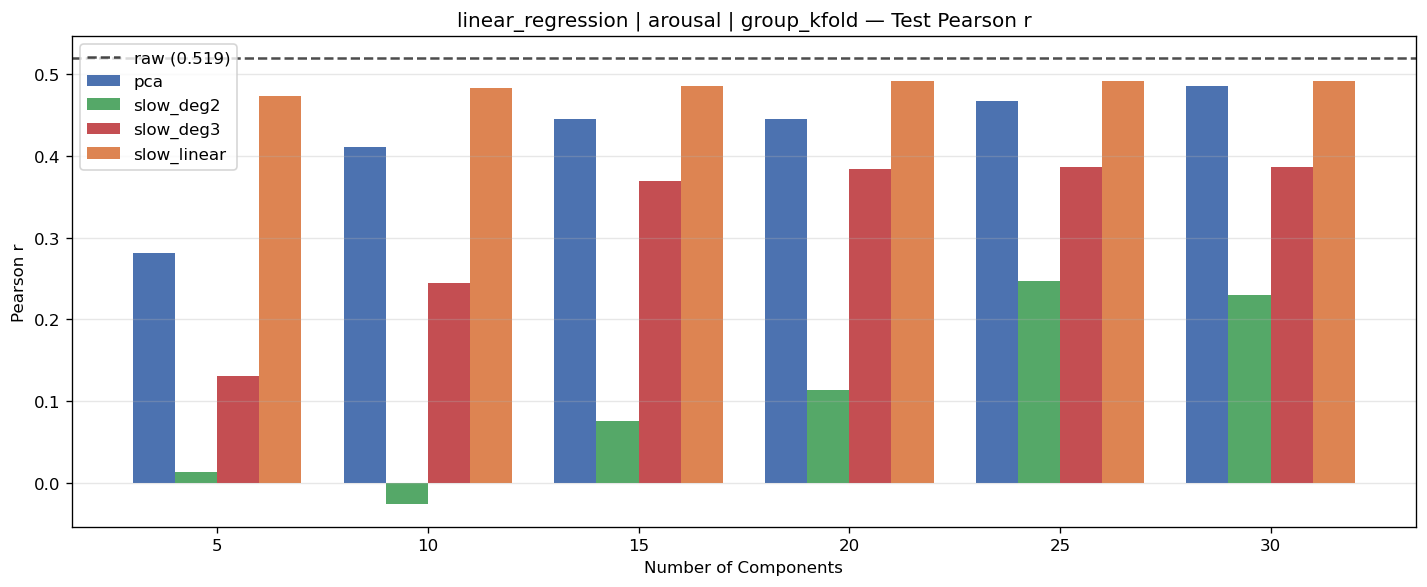

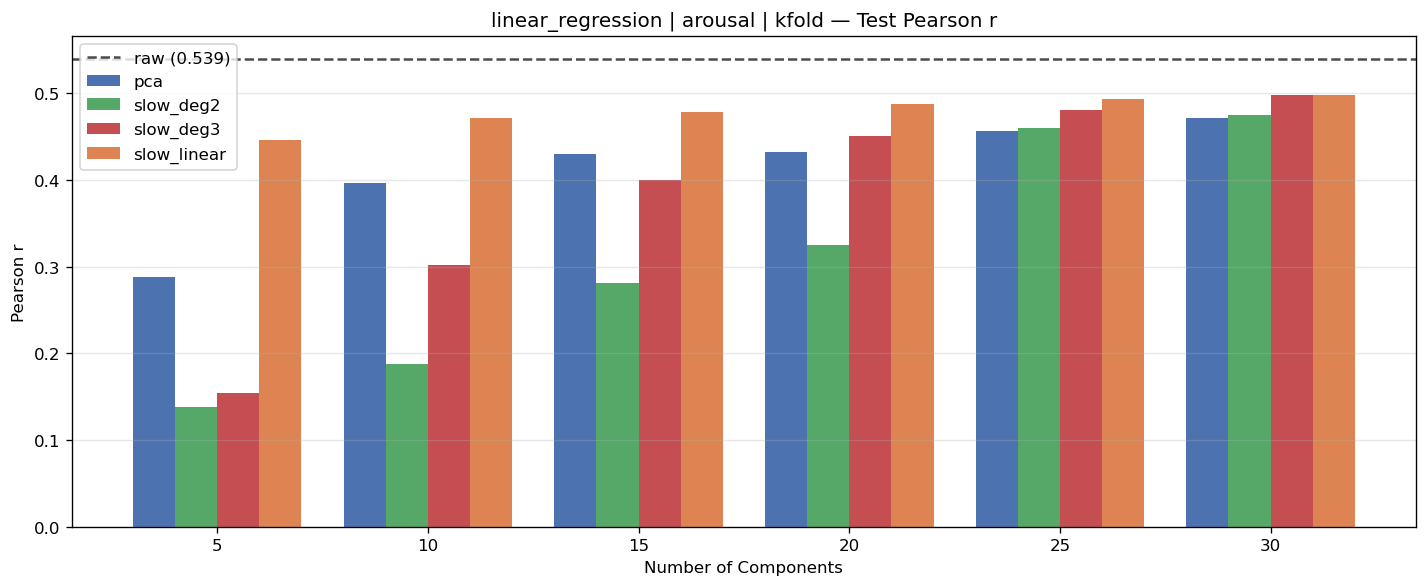

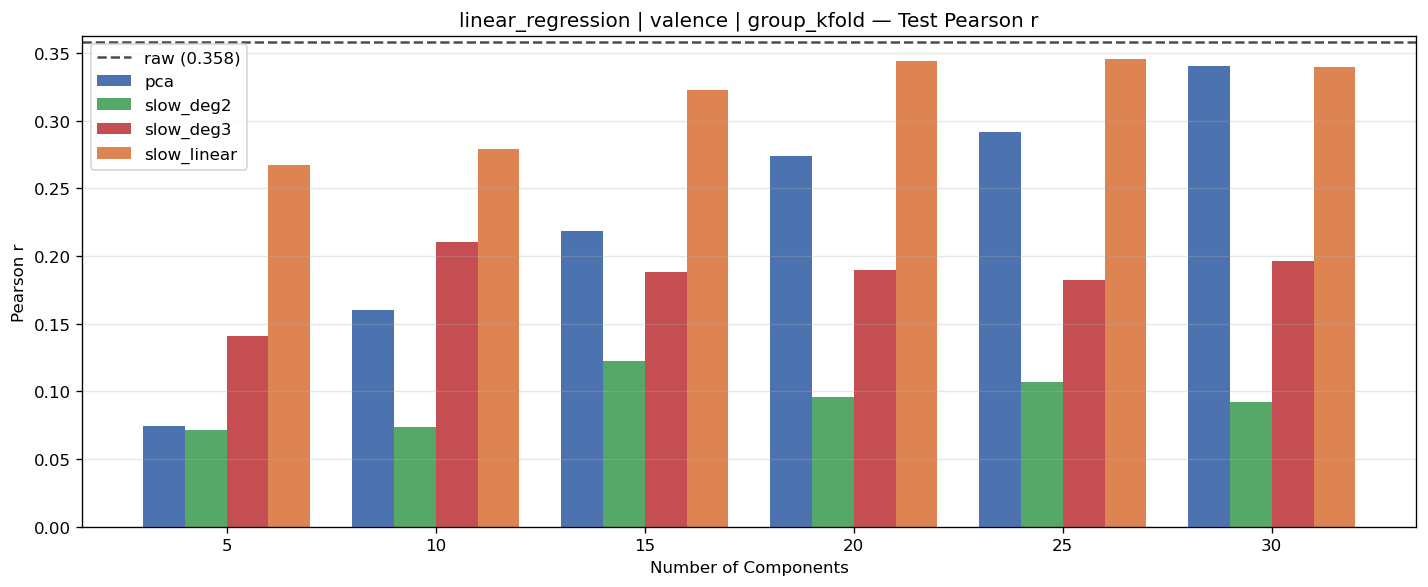

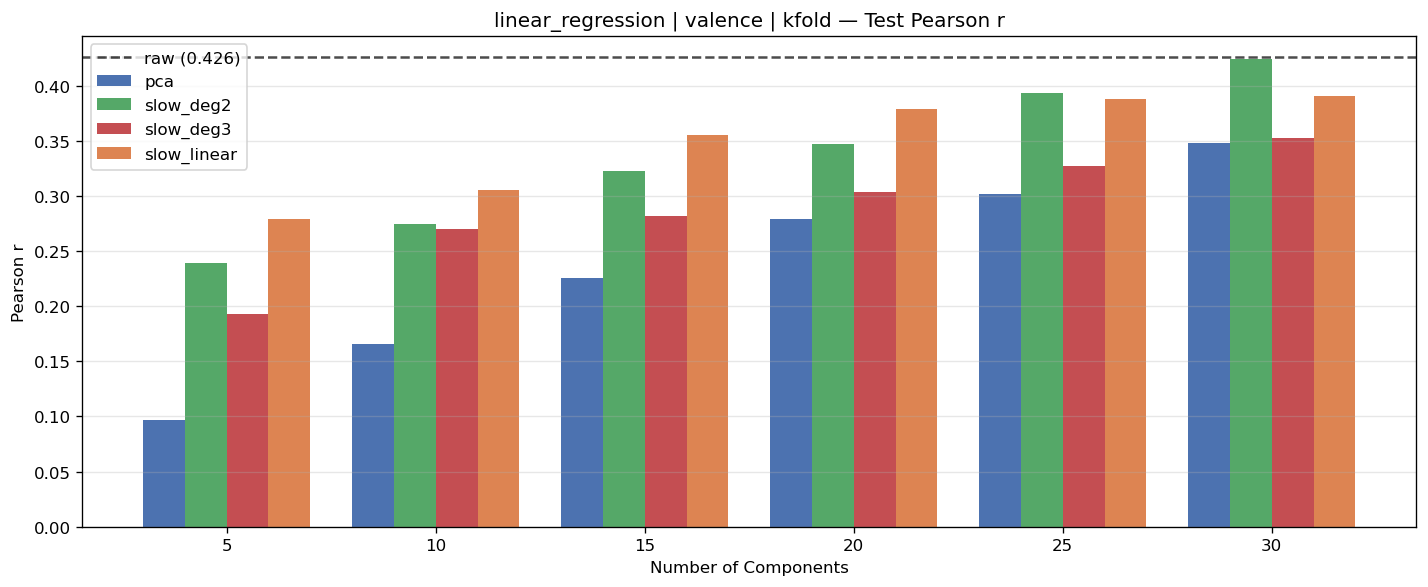

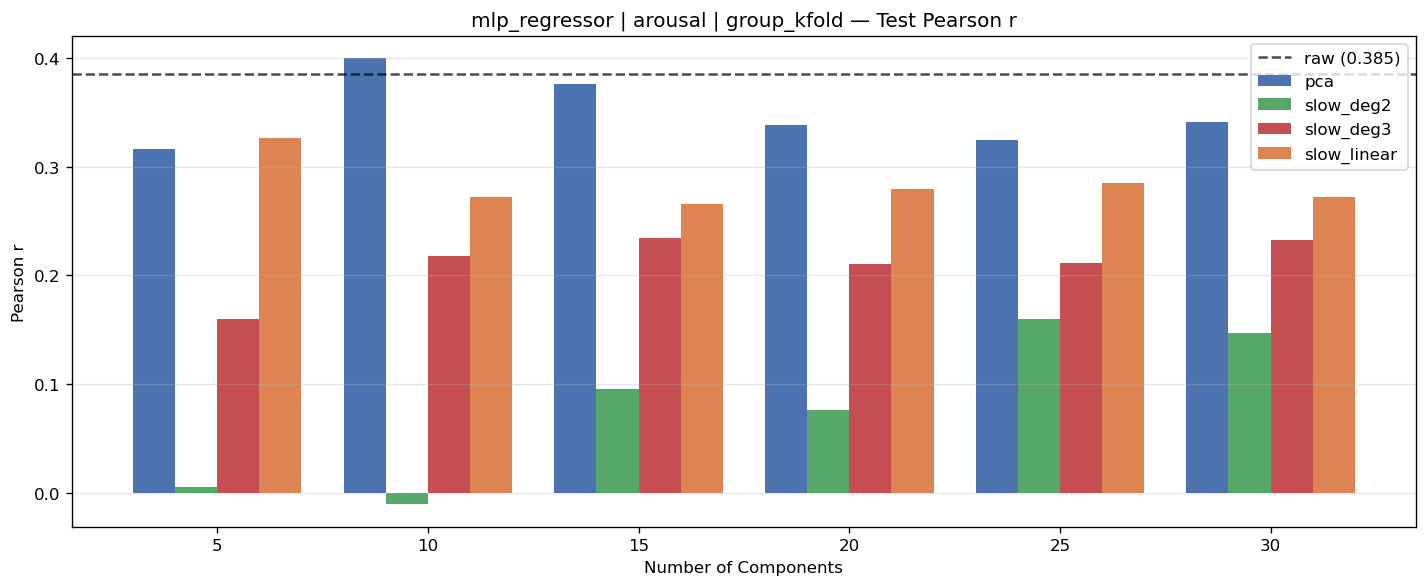

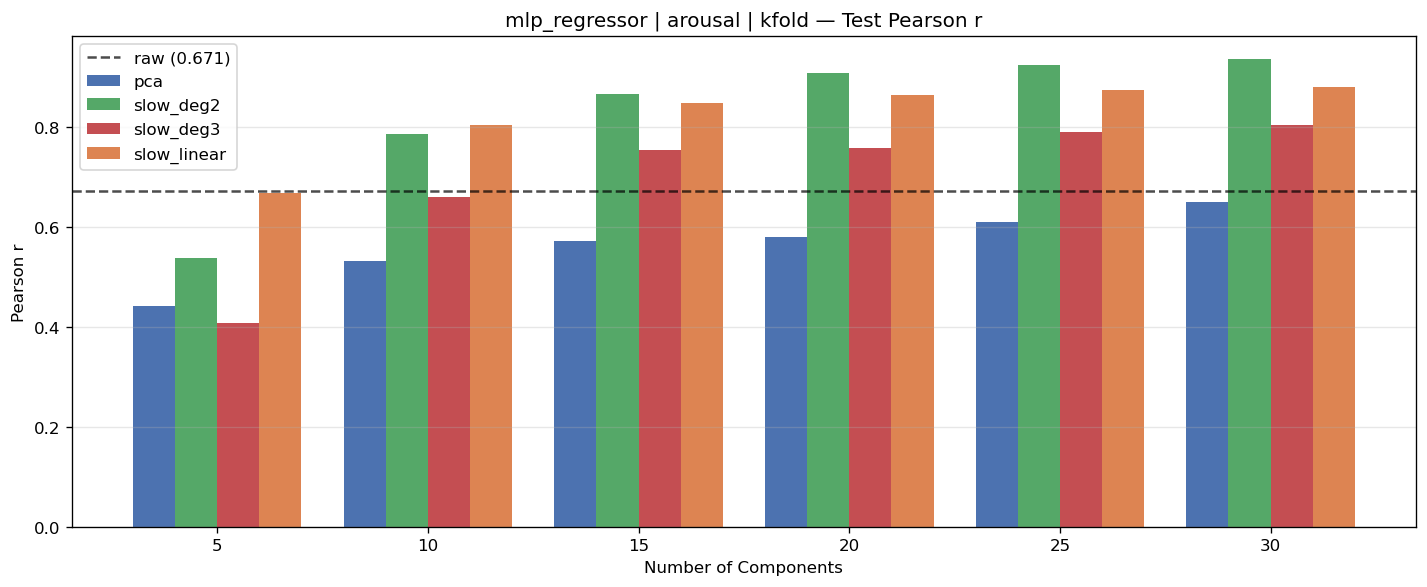

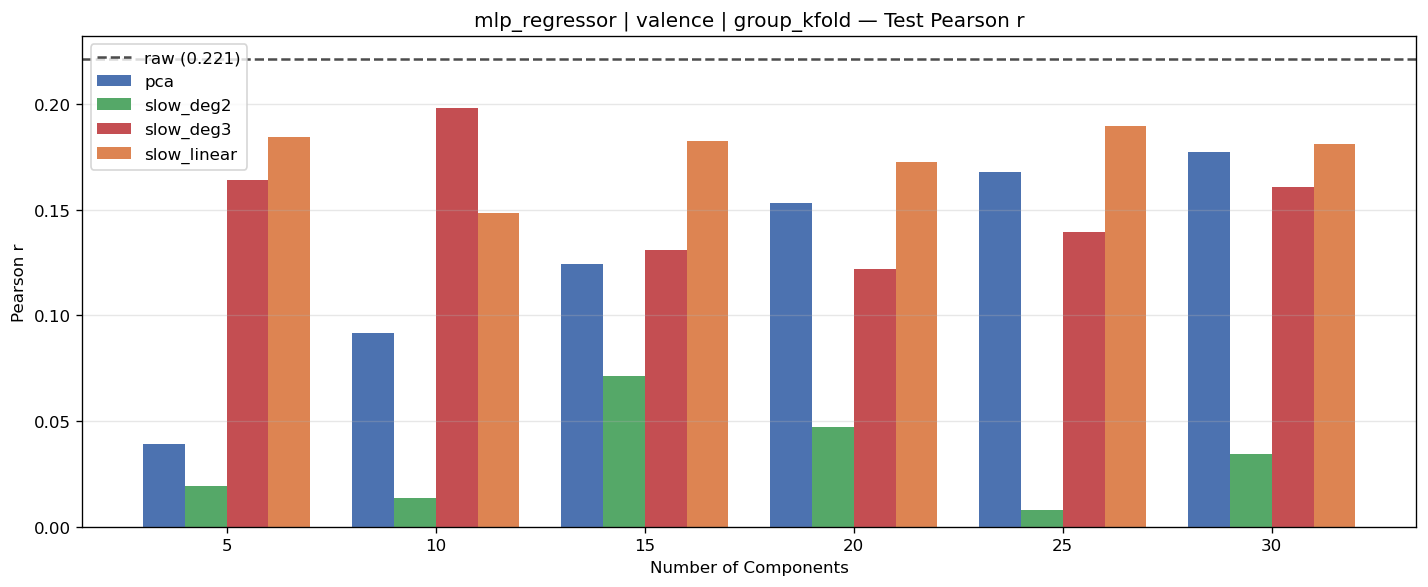

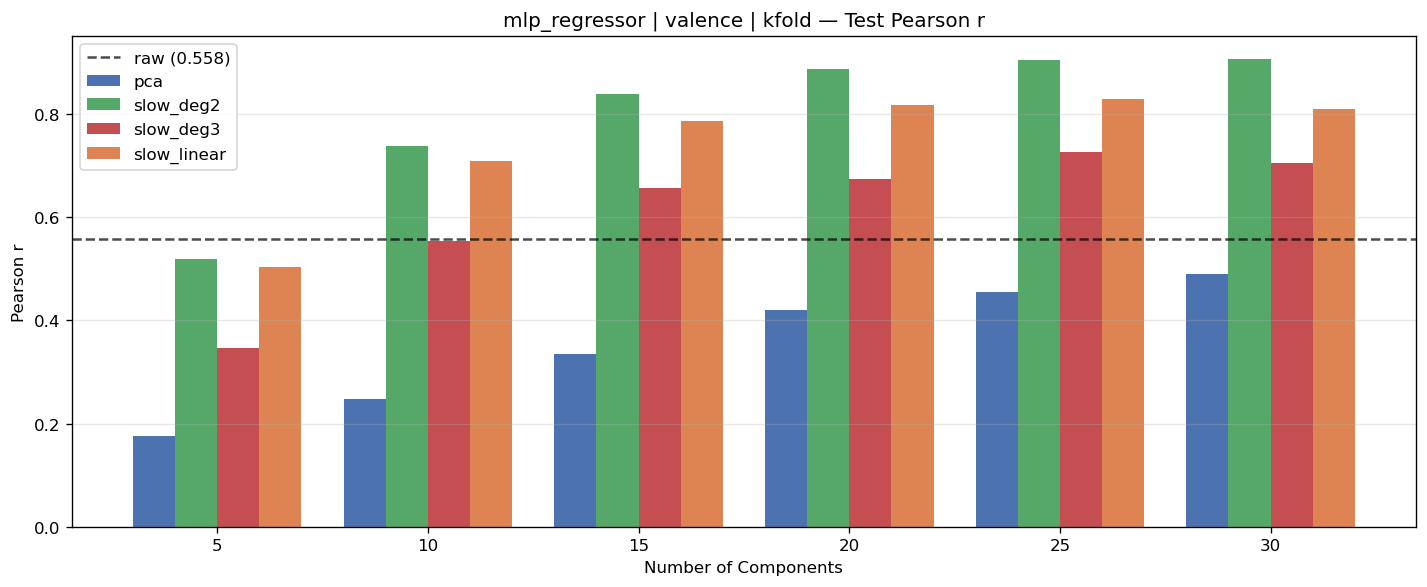

In [10]:
def plot_metric_by_components(df_subset, metric_col, title, ylabel, filename=None):
    """
    Grouped bar chart: x-axis = n_components, groups = feature_type.
    Only includes feature types that have components (excludes 'raw').
    """
    # Filter to rows that have components
    plot_df = df_subset[df_subset["n_components"].notna()].copy()
    plot_df["n_components"] = plot_df["n_components"].astype(int)

    feature_types = sorted(plot_df["feature_type"].unique())
    dims = sorted(plot_df["n_components"].unique())

    n_types = len(feature_types)
    x = np.arange(len(dims))
    width = 0.8 / n_types

    colors = {"pca": "#4C72B0", "slow_linear": "#DD8452",
              "slow_deg2": "#55A868", "slow_deg3": "#C44E52"}

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, ft in enumerate(feature_types):
        ft_data = plot_df[plot_df["feature_type"] == ft]
        vals = []
        for d in dims:
            row = ft_data[ft_data["n_components"] == d]
            vals.append(row[metric_col].values[0] if len(row) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=ft, color=colors.get(ft, "gray"))

    # Add raw baseline as horizontal line if present
    raw_rows = df_subset[df_subset["feature_type"] == "raw"]
    if len(raw_rows) > 0:
        raw_val = raw_rows[metric_col].values[0]
        ax.axhline(y=raw_val, color="black", linestyle="--", alpha=0.7, label=f"raw ({raw_val:.3f})")

    ax.set_xlabel("Number of Components")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x + width * (n_types - 1) / 2)
    ax.set_xticklabels(dims)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


# Plot for each model x target x cv_scheme (regression)
for model_name in REGRESSION_MODELS:
    for target_name in ["arousal", "valence"]:
        for cv in CV_SCHEMES:
            subset = df_reg[
                (df_reg["model"] == model_name) &
                (df_reg["target"] == target_name) &
                (df_reg["cv_scheme"] == cv)
            ]
            if subset.empty:
                continue
            fname = f"results/reg_{model_name}_{target_name}_{cv}_pearsonr.png"
            plot_metric_by_components(
                subset, "test_pearson_r_mean",
                f"{model_name} | {target_name} | {cv} — Test Pearson r",
                "Pearson r",
                filename=fname,
            )

### 6b. Classification — Accuracy Across Feature Types

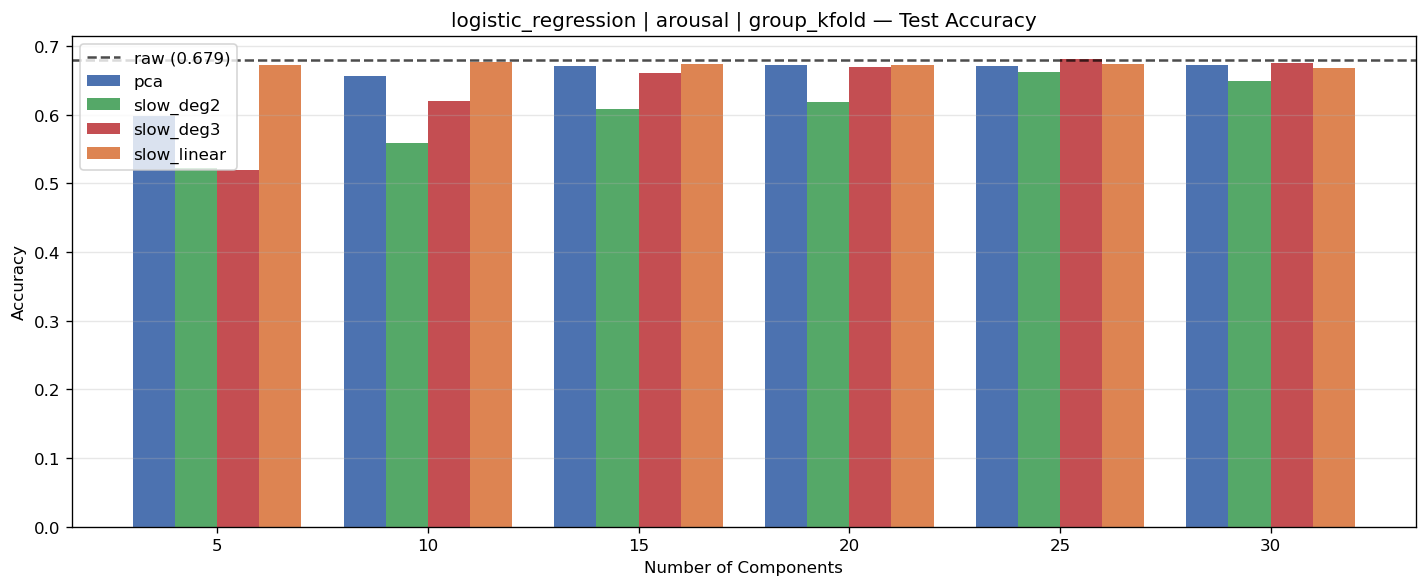

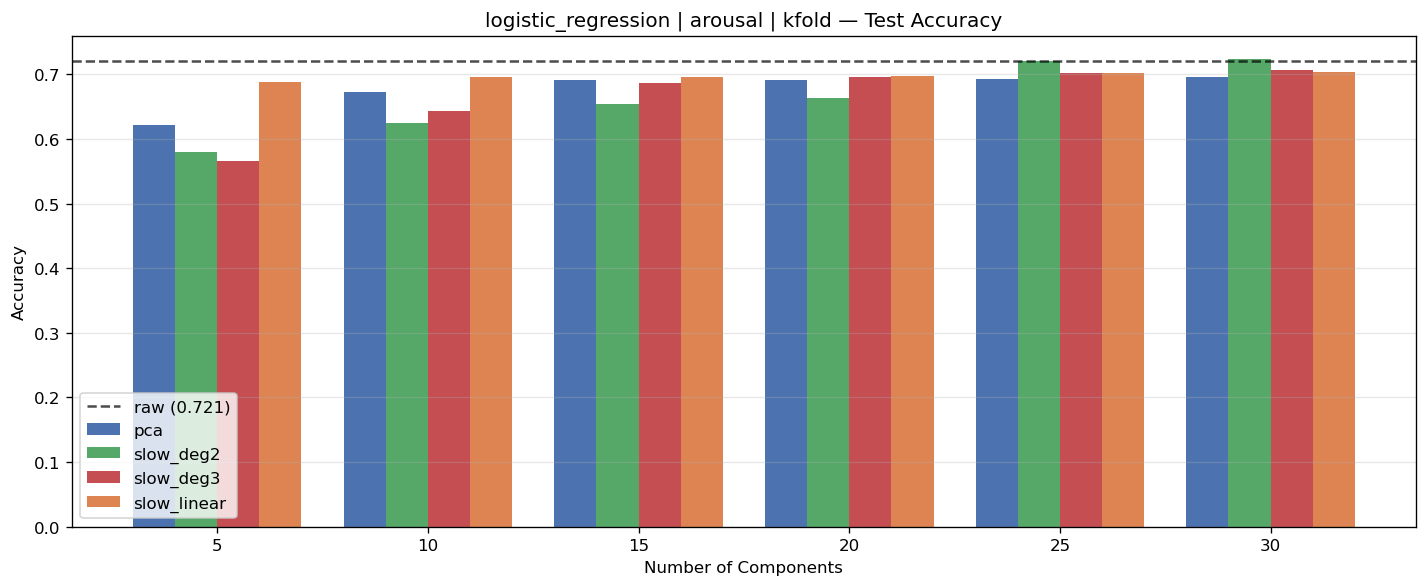

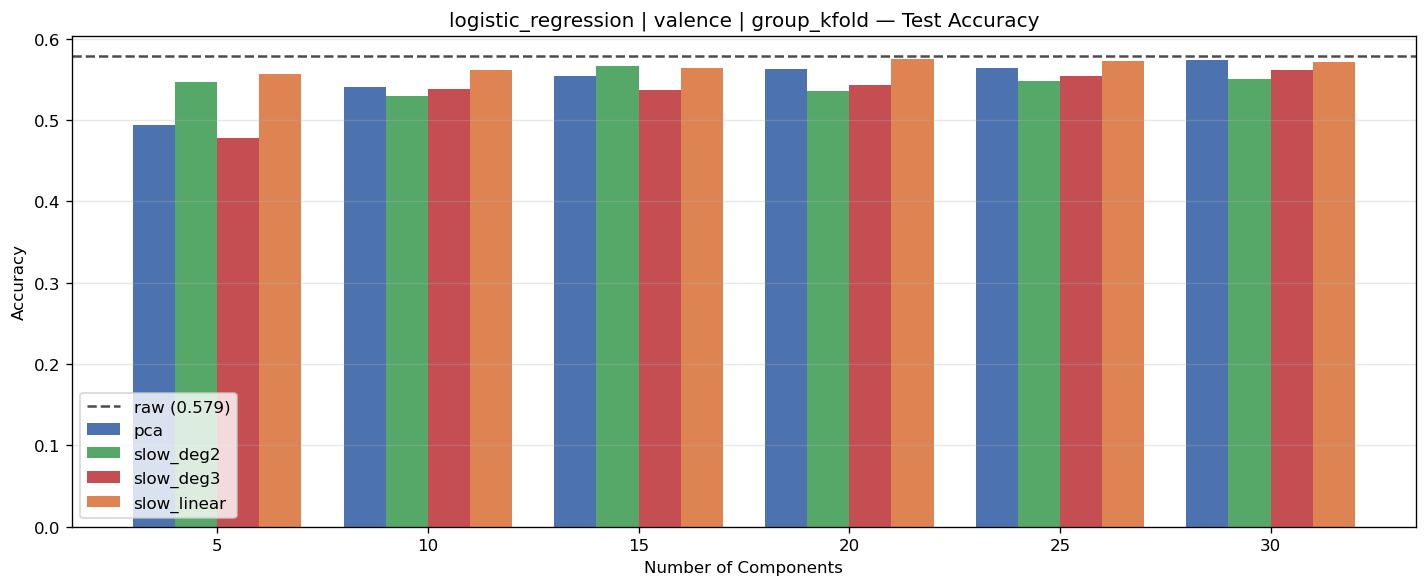

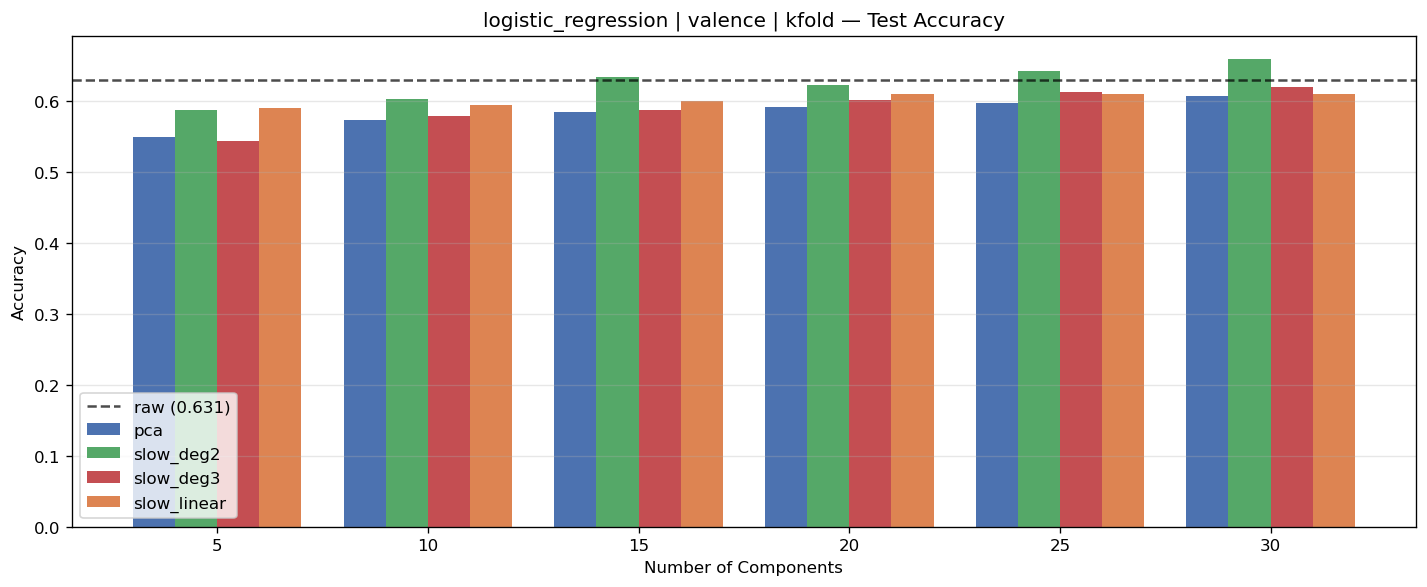

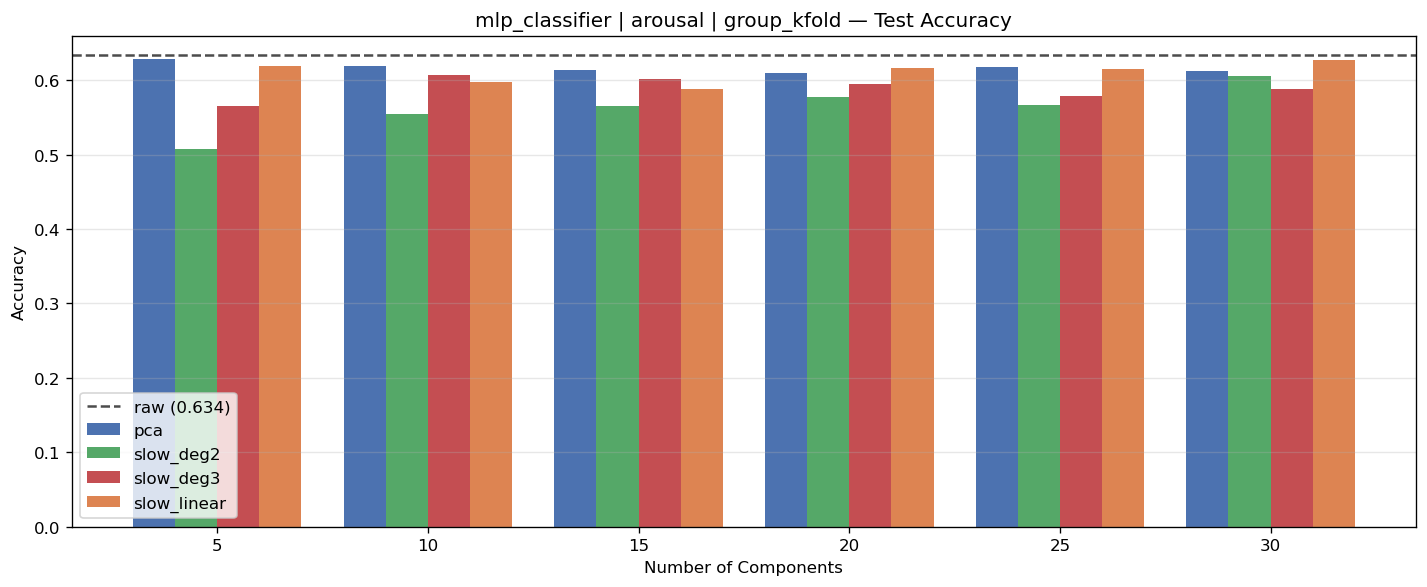

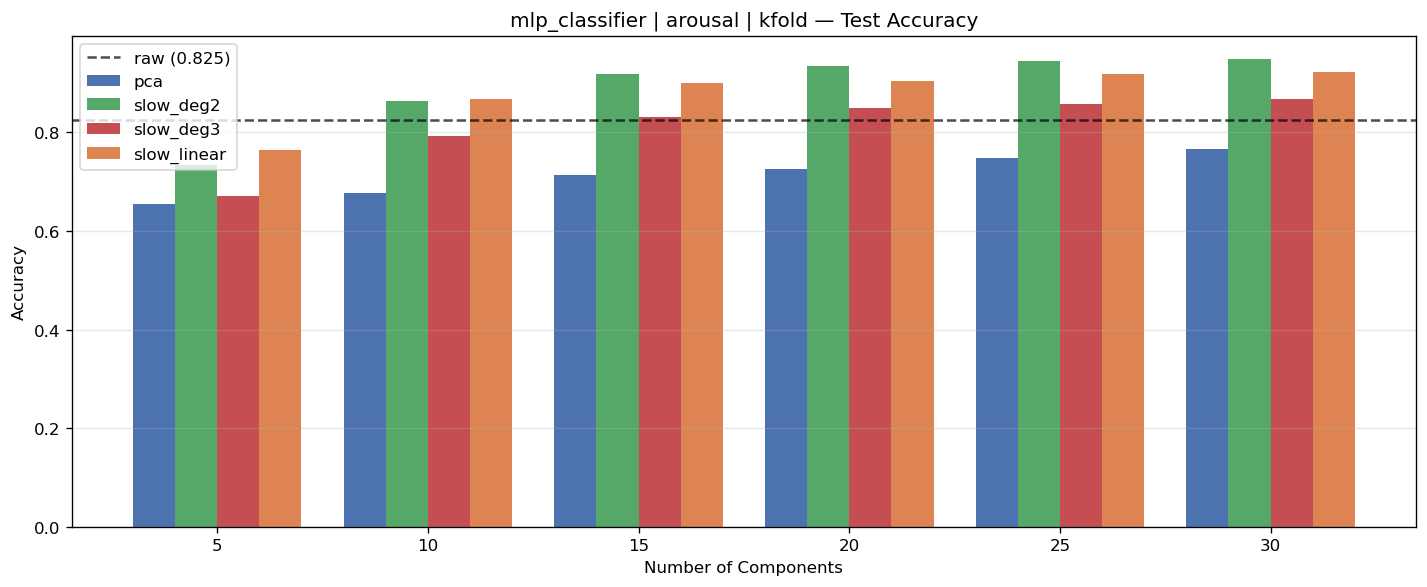

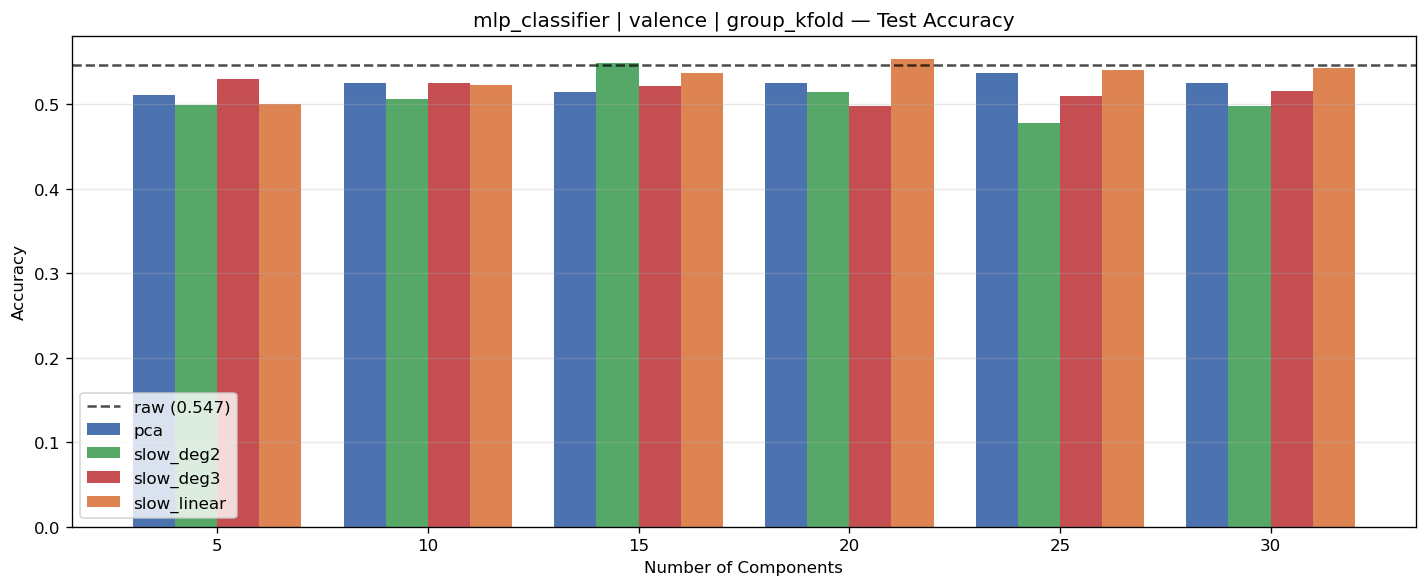

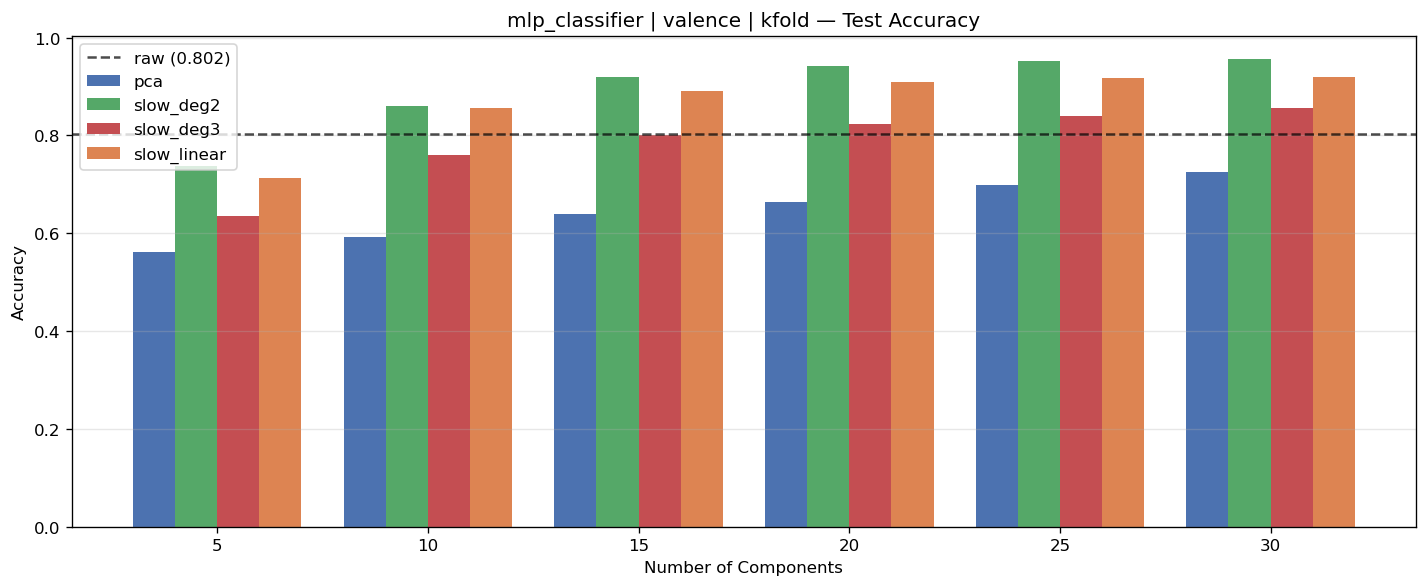

In [11]:
for model_name in CLASSIFICATION_MODELS:
    for target_name in ["arousal", "valence"]:
        for cv in CV_SCHEMES:
            subset = df_clf[
                (df_clf["model"] == model_name) &
                (df_clf["target"] == target_name) &
                (df_clf["cv_scheme"] == cv)
            ]
            if subset.empty:
                continue
            fname = f"results/clf_{model_name}_{target_name}_{cv}_accuracy.png"
            plot_metric_by_components(
                subset, "test_accuracy_mean",
                f"{model_name} | {target_name} | {cv} — Test Accuracy",
                "Accuracy",
                filename=fname,
            )

### 6c. Heatmap — PCA vs SFA (Group K-Fold)

Side-by-side heatmaps comparing PCA baseline against each SFA variant
across all component dimensions, for a selected model and target.

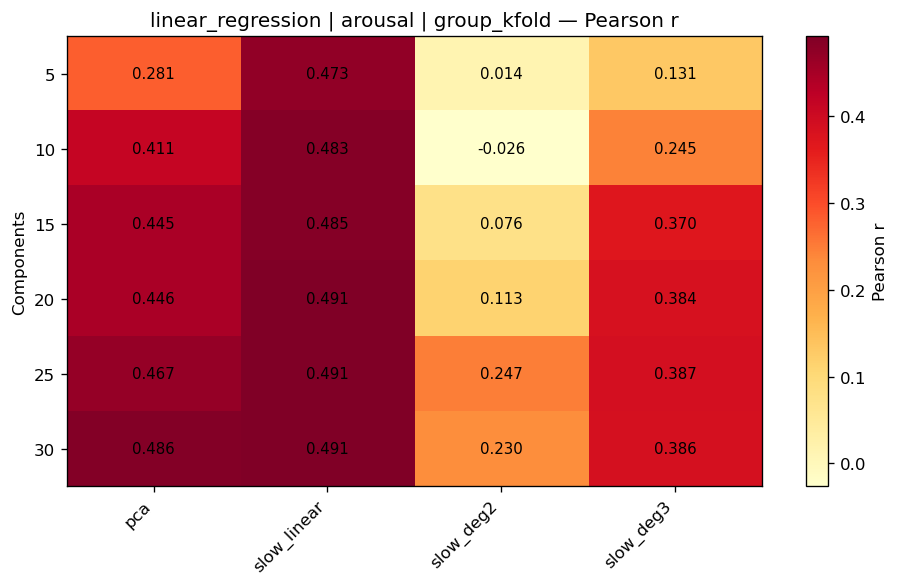

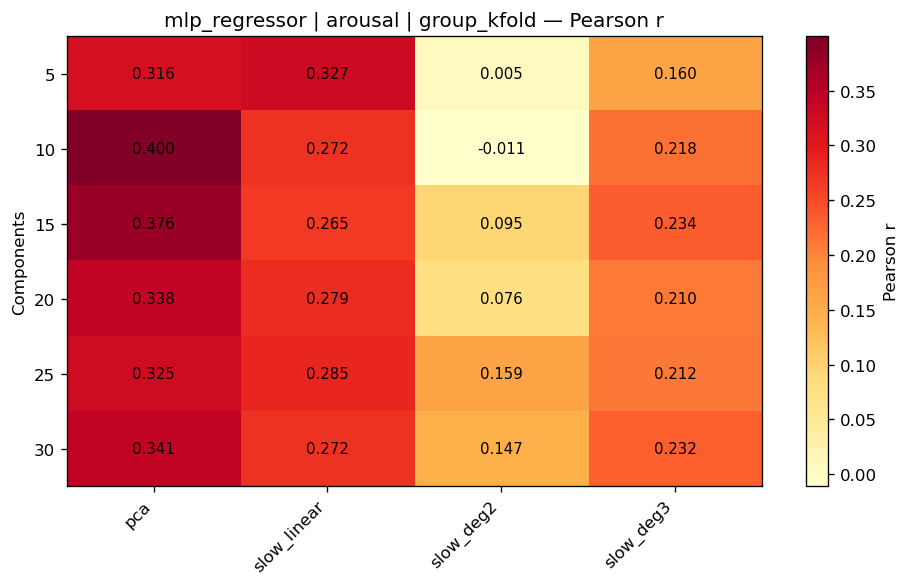

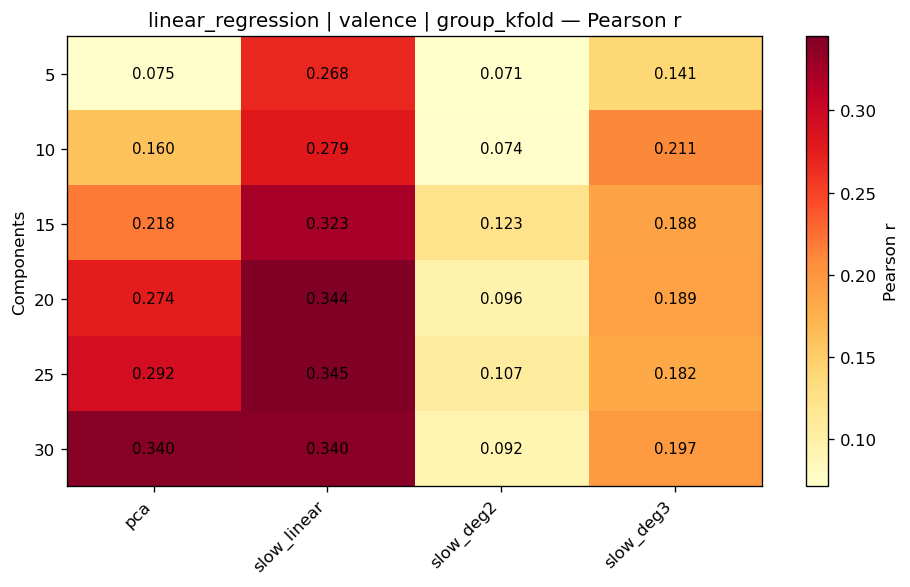

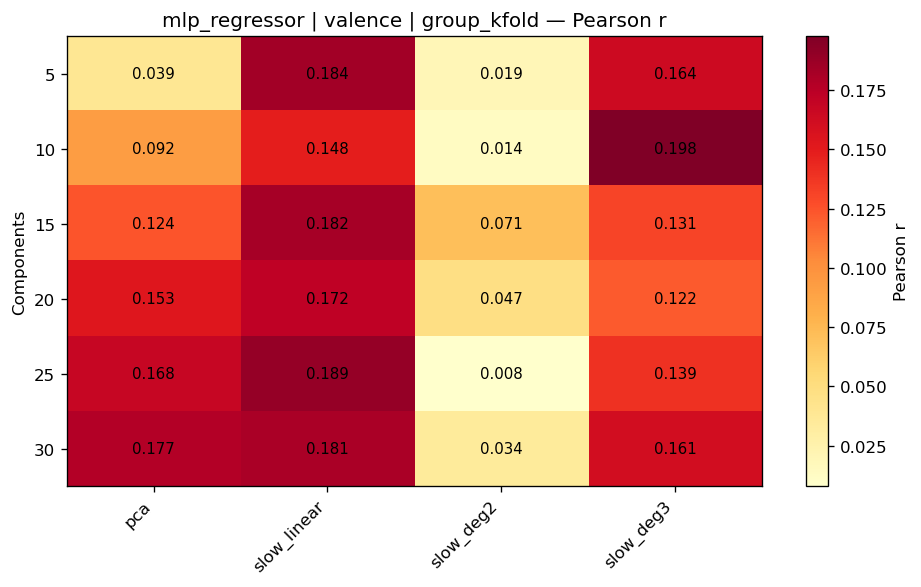

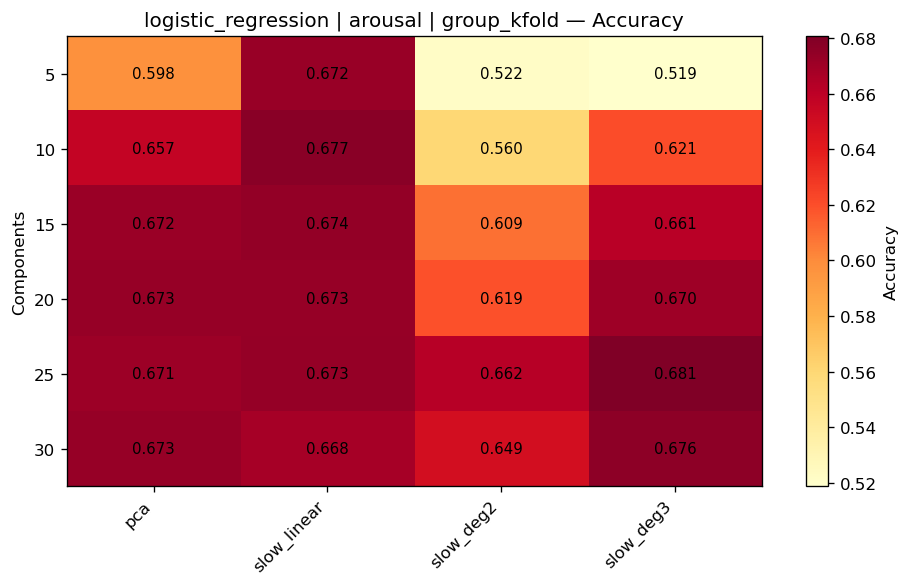

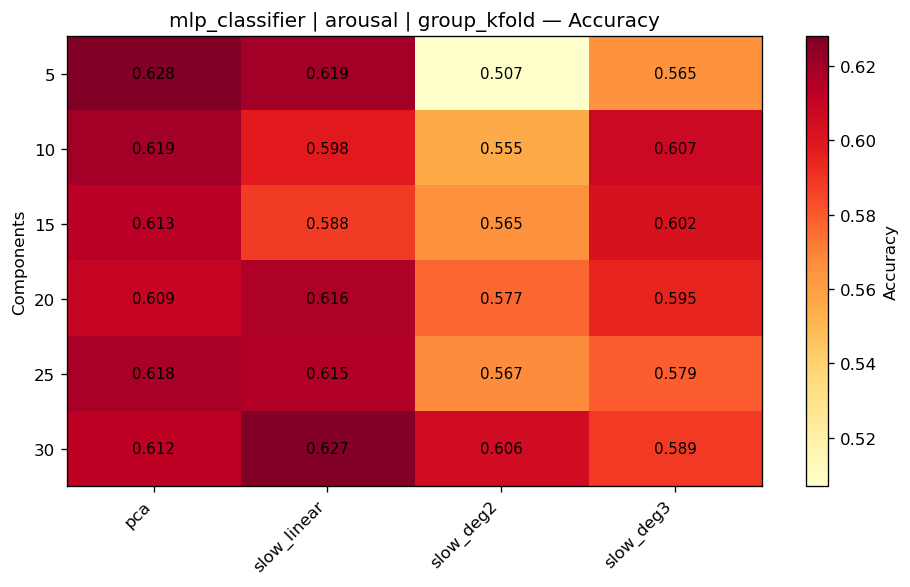

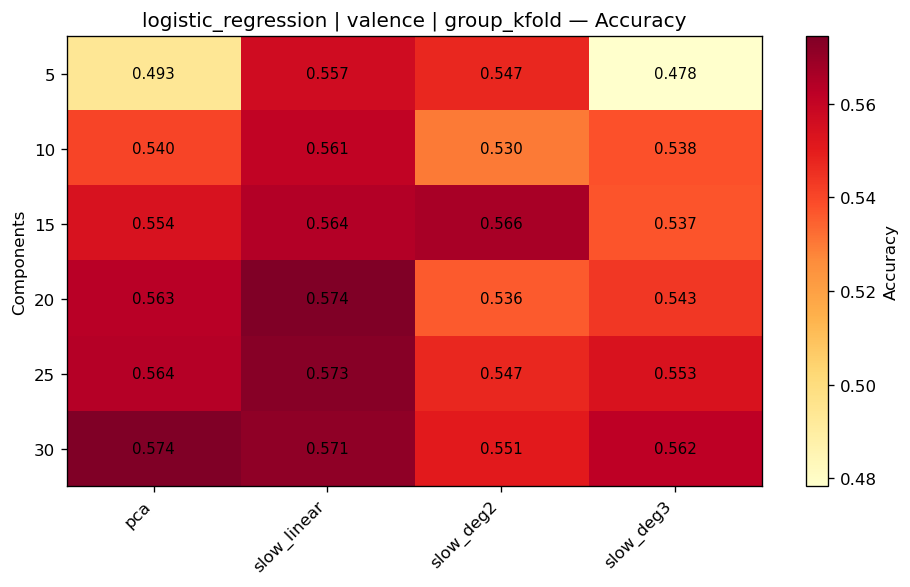

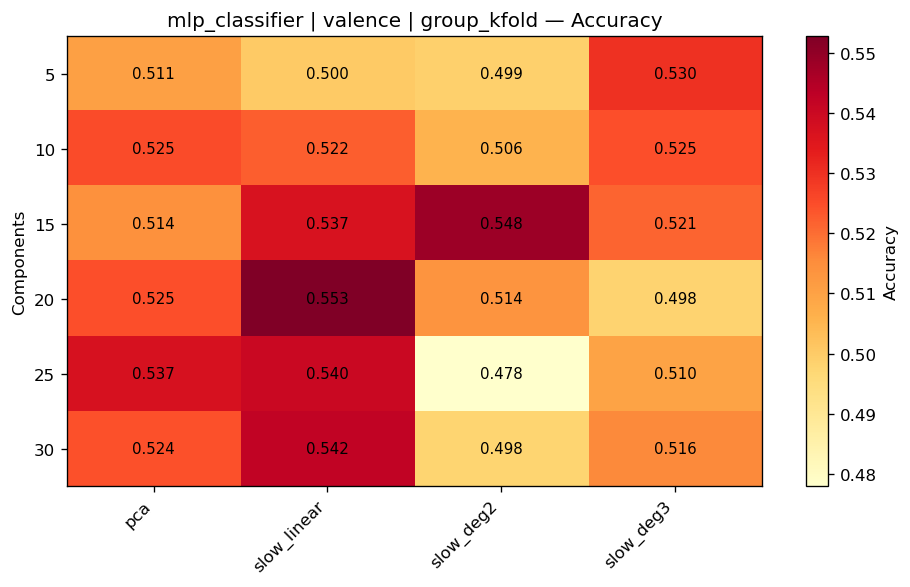

In [12]:
def plot_heatmap_comparison(df_task, task, metric_col, metric_label,
                            cv="group_kfold", filename=None):
    """
    Heatmap: rows = component dimensions, columns = feature types,
    one heatmap per model x target.
    """
    feature_types = ["pca", "slow_linear", "slow_deg2", "slow_deg3"]

    subset = df_task[df_task["cv_scheme"] == cv].copy()
    subset = subset[subset["feature_type"].isin(feature_types)]
    subset = subset[subset["n_components"].notna()]
    subset["n_components"] = subset["n_components"].astype(int)

    models = REGRESSION_MODELS if task == "regression" else CLASSIFICATION_MODELS

    for target_name in ["arousal", "valence"]:
        for model_name in models:
            sub = subset[
                (subset["target"] == target_name) &
                (subset["model"] == model_name)
            ]
            if sub.empty:
                continue

            pivot = sub.pivot_table(
                index="n_components",
                columns="feature_type",
                values=metric_col,
                aggfunc="first",
            )
            # Reorder columns
            pivot = pivot.reindex(columns=[ft for ft in feature_types if ft in pivot.columns])

            fig, ax = plt.subplots(figsize=(8, 5))
            im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_ylabel("Components")

            # Annotate cells
            for i in range(len(pivot.index)):
                for j in range(len(pivot.columns)):
                    val = pivot.values[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)

            plt.colorbar(im, ax=ax, label=metric_label)
            ax.set_title(f"{model_name} | {target_name} | {cv} — {metric_label}")
            plt.tight_layout()
            if filename:
                fn = filename.format(model=model_name, target=target_name)
                plt.savefig(fn, dpi=150, bbox_inches="tight")
            plt.show()


# Regression heatmaps
plot_heatmap_comparison(
    df_reg, "regression", "test_pearson_r_mean", "Pearson r",
    cv="group_kfold",
    filename="results/heatmap_reg_{model}_{target}_gkf.png",
)

# Classification heatmaps
plot_heatmap_comparison(
    df_clf, "classification", "test_accuracy_mean", "Accuracy",
    cv="group_kfold",
    filename="results/heatmap_clf_{model}_{target}_gkf.png",
)

### 6d. Group K-Fold vs K-Fold Comparison

Compare how models perform under Leave-One-Participant-Out vs standard K-Fold.
This directly tests the thesis claim: if SFA features are more invariant across
participants, the gap between Group K-Fold and K-Fold should be smaller for SFA
than for raw/PCA features.

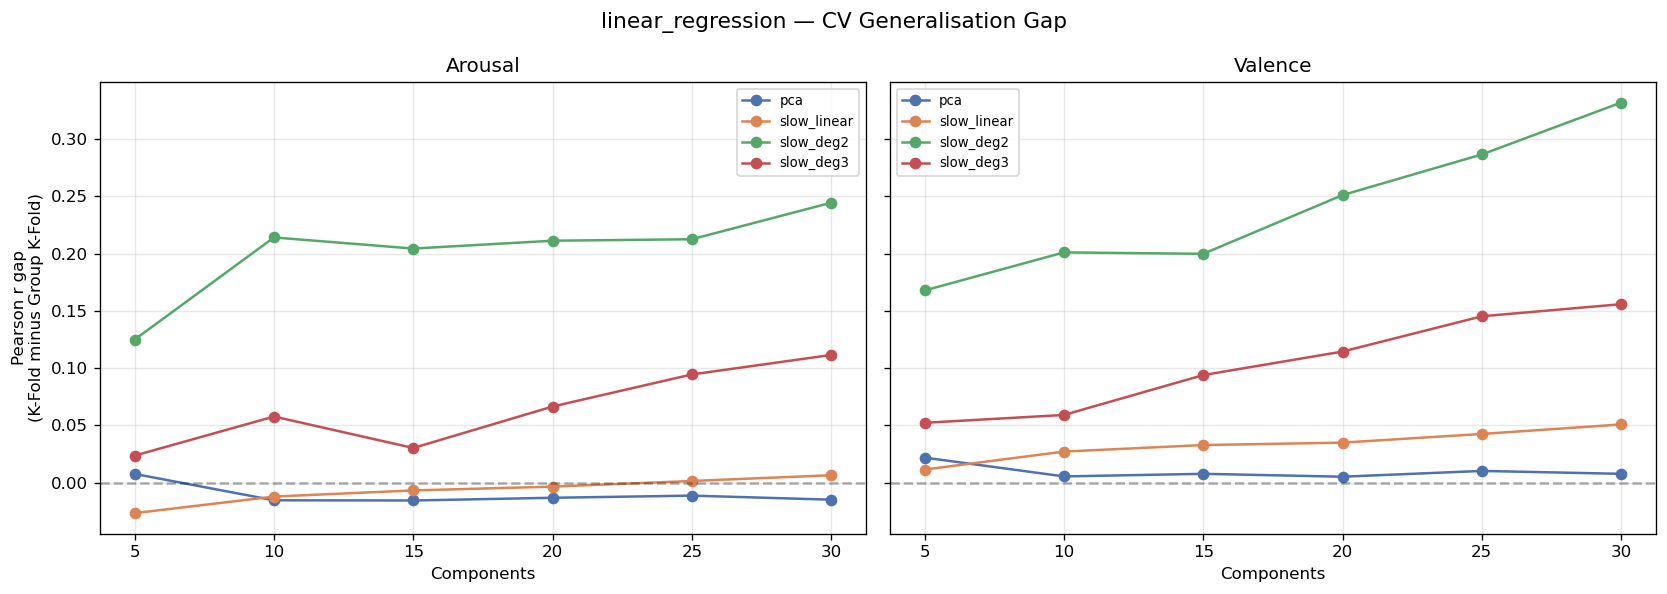

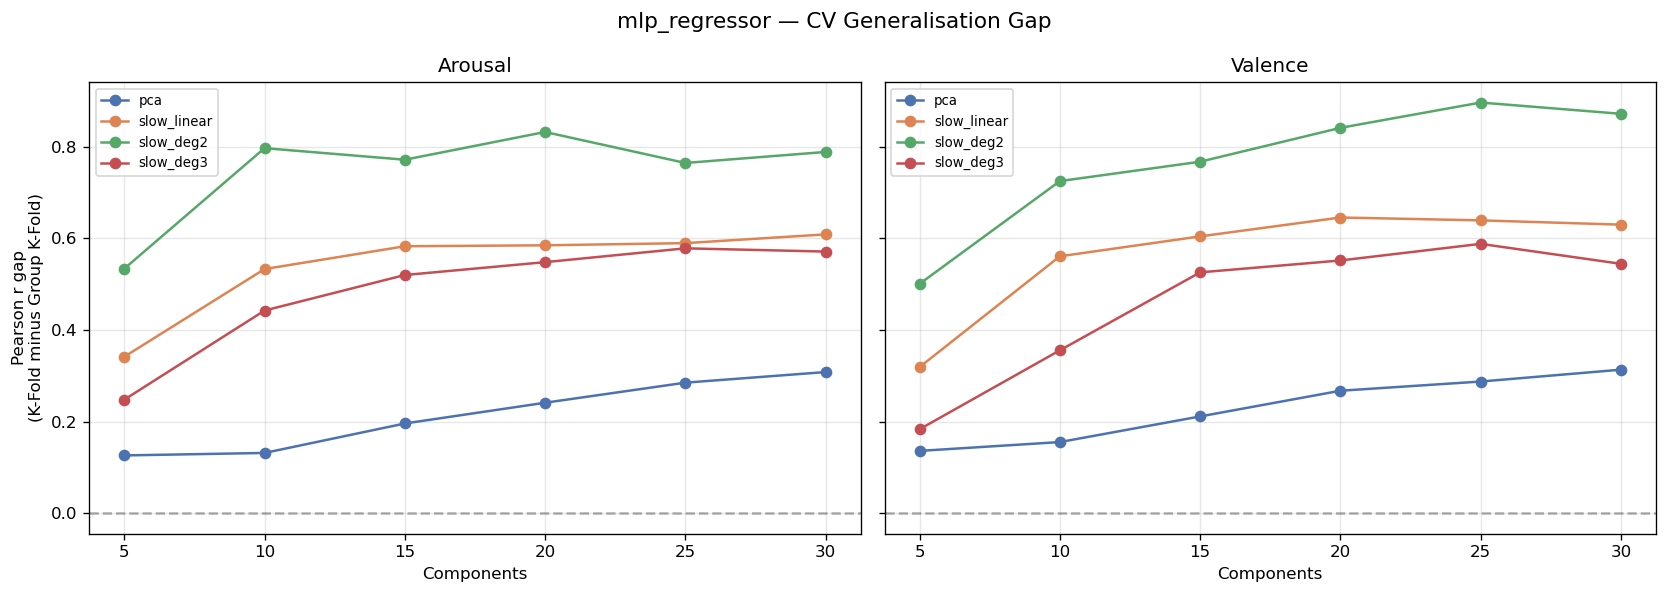

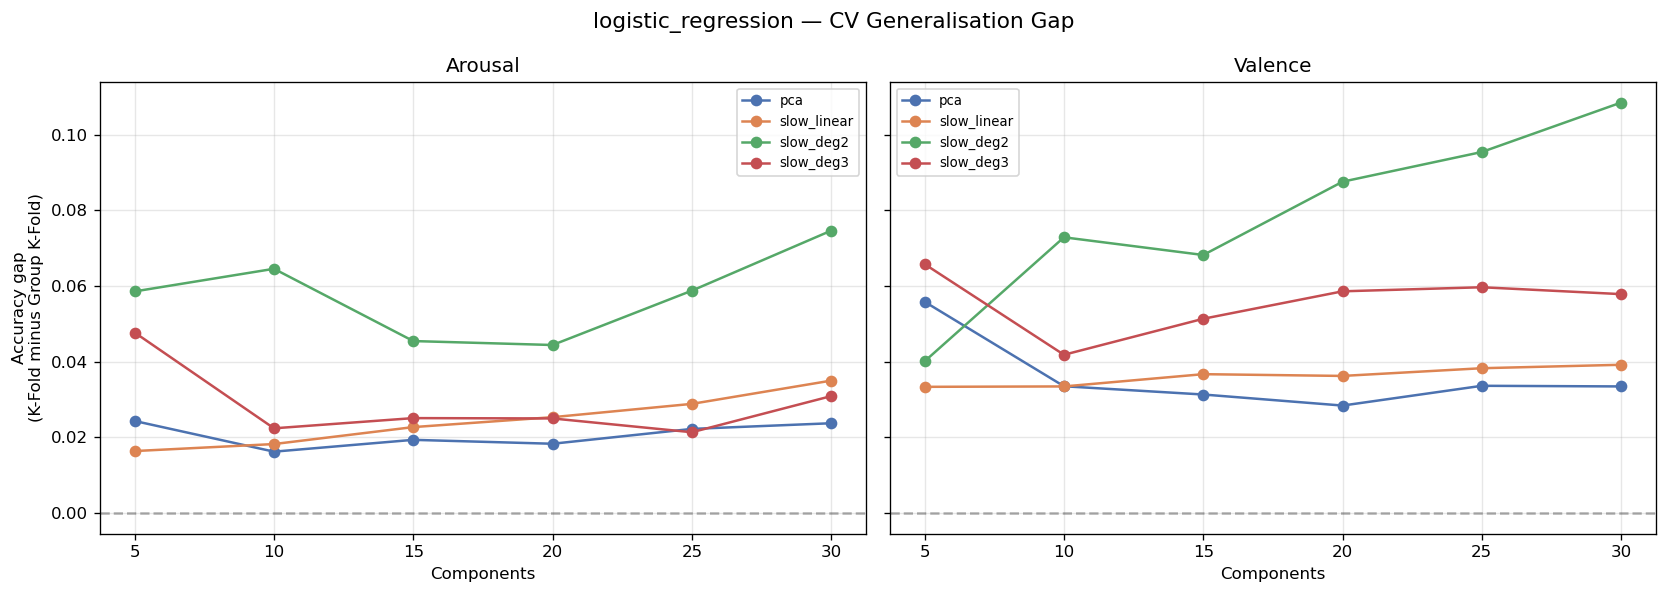

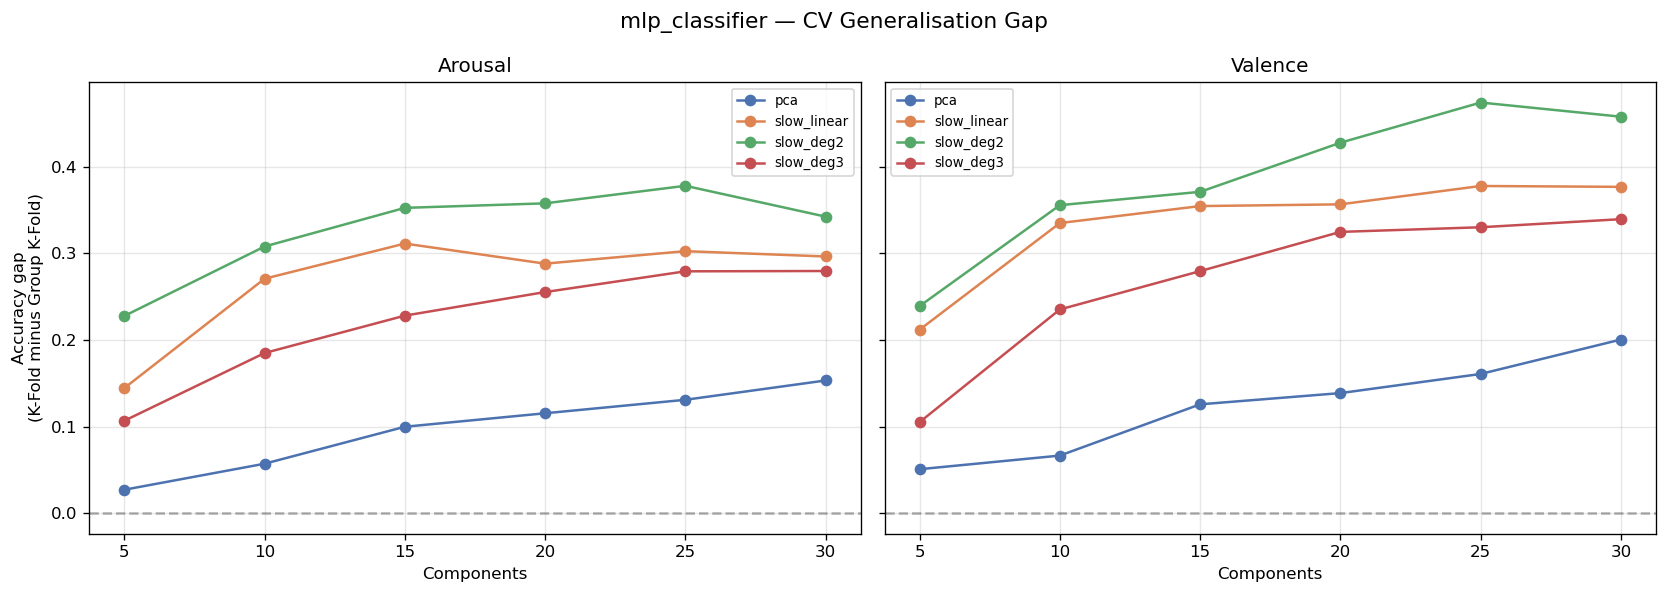

In [13]:
def plot_cv_gap(df_task, task, metric_col, metric_label, model_name, filename=None):
    """
    For each feature type x n_components, show the difference between
    K-Fold and Group K-Fold performance. A smaller gap suggests better
    cross-participant generalisation.
    """
    feature_types = ["pca", "slow_linear", "slow_deg2", "slow_deg3"]
    colors = {"pca": "#4C72B0", "slow_linear": "#DD8452",
              "slow_deg2": "#55A868", "slow_deg3": "#C44E52"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, target_name in zip(axes, ["arousal", "valence"]):
        for ft in feature_types:
            gkf = df_task[
                (df_task["model"] == model_name) &
                (df_task["target"] == target_name) &
                (df_task["cv_scheme"] == "group_kfold") &
                (df_task["feature_type"] == ft) &
                (df_task["n_components"].notna())
            ].sort_values("n_components")

            kf = df_task[
                (df_task["model"] == model_name) &
                (df_task["target"] == target_name) &
                (df_task["cv_scheme"] == "kfold") &
                (df_task["feature_type"] == ft) &
                (df_task["n_components"].notna())
            ].sort_values("n_components")

            if gkf.empty or kf.empty:
                continue

            dims = gkf["n_components"].astype(int).values
            gap = kf[metric_col].values - gkf[metric_col].values
            ax.plot(dims, gap, "o-", label=ft, color=colors.get(ft, "gray"))

        ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
        ax.set_xlabel("Components")
        ax.set_title(f"{target_name.capitalize()}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(f"{metric_label} gap\n(K-Fold minus Group K-Fold)")
    fig.suptitle(f"{model_name} — CV Generalisation Gap", fontsize=13)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


for model_name in REGRESSION_MODELS:
    plot_cv_gap(df_reg, "regression", "test_pearson_r_mean", "Pearson r",
               model_name, filename=f"results/cv_gap_reg_{model_name}.png")

for model_name in CLASSIFICATION_MODELS:
    plot_cv_gap(df_clf, "classification", "test_accuracy_mean", "Accuracy",
               model_name, filename=f"results/cv_gap_clf_{model_name}.png")

## 7. Export Results

Save the summary DataFrame as CSV (for easy viewing/sharing) and the
full per-fold results as pickle (for further analysis).

In [14]:
os.makedirs("results", exist_ok=True)

# CSV summary (one row per experiment, mean/std across folds)
csv_path = "results/experiment_summary.csv"
df.to_csv(csv_path, index=False)
print(f"Saved summary CSV: {csv_path} ({df.shape[0]} rows)")

# Separate CSVs for regression and classification
df_reg.to_csv("results/regression_summary.csv", index=False)
df_clf.to_csv("results/classification_summary.csv", index=False)
print(f"Saved: results/regression_summary.csv ({df_reg.shape[0]} rows)")
print(f"Saved: results/classification_summary.csv ({df_clf.shape[0]} rows)")

Saved summary CSV: results/experiment_summary.csv (400 rows)
Saved: results/regression_summary.csv (200 rows)
Saved: results/classification_summary.csv (200 rows)


## 8. Summary

### Output files

| File | Description |
|------|-------------|
| `results/experiment_results.pkl` | Full per-fold results (pickle) |
| `results/experiment_summary.csv` | Aggregated mean/std per experiment |
| `results/regression_summary.csv` | Regression results only |
| `results/classification_summary.csv` | Classification results only |
| `results/*.png` | Comparison visualisations |

### Key questions these results answer

1. **Do SFA features outperform PCA at equivalent dimensionality?** → Compare PCA vs SFA columns in pivot tables
2. **Which SFA variant (linear, deg2, deg3) works best?** → Compare across SFA rows
3. **Do SFA features generalise better across participants?** → Compare Group K-Fold vs K-Fold gap
4. **Are results consistent across arousal and valence?** → Compare target columns
5. **Do nonlinear models (MLP) benefit more from SFA than linear models?** → Compare model columns